# 02 — Dosimetric Feature Extraction

Loads `data/processed/modeling_table.csv` (190 patients, post DVH QC) and
produces descriptive statistics and DVH visualisations.

**Figures saved to:** `figures/02_*.png`

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import DATA_PROCESSED, FIGURES_DIR
from src.data.dvh_calculator import SCALAR_METRIC_KEYS
from src.utils.plot_dvh import plot_dvh_overlay, load_dvh_curve

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
COLORS = ["#2c7bb6", "#d7191c", "#fdae61", "#1a9641"]

In [2]:
modeling = pd.read_csv(DATA_PROCESSED / "modeling_table.csv")
metric_cols = [c for c in SCALAR_METRIC_KEYS if c in modeling.columns]

assert len(modeling) == 190, f"expected 190 patients, got {len(modeling)}"
assert len(metric_cols) == 21, f"expected 21 DVH metrics, got {len(metric_cols)}"

print(f"Modeling cohort: {len(modeling)} patients, {len(metric_cols)} DVH metrics")
print(f"Fractionation: 60 Gy/30 fr = {(modeling['rt_dose_gy']==60).sum()}, "
      f"40.05 Gy/15 fr = {(modeling['rt_dose_gy']==40.05).sum()}")

Modeling cohort: 190 patients, 21 DVH metrics
Fractionation: 60 Gy/30 fr = 120, 40.05 Gy/15 fr = 61


## 1. DVH scalar summary statistics

In [3]:
summary = modeling[metric_cols].describe().T
summary = summary[["count", "mean", "std", "min", "50%", "max"]]
summary.columns = ["n", "mean", "std", "min", "median", "max"]
print(summary.round(2).to_string())

                  n    mean    std     min  median     max
D2_gy         190.0   54.32   9.72   25.53   60.83   62.52
D5_gy         190.0   54.11   9.67   25.43   60.65   62.39
D10_gy        190.0   53.92   9.64   25.33   60.50   62.28
D25_gy        190.0   53.61   9.58   25.12   60.23   62.10
D50_gy        190.0   53.23   9.52   24.91   59.85   61.87
D90_gy        190.0   52.48   9.39   24.60   58.96   61.34
D95_gy        190.0   52.24   9.33   24.53   58.69   61.17
D98_gy        190.0   51.88   9.23   24.46   58.23   60.98
V20_pct       190.0  100.00   0.00  100.00  100.00  100.00
V40_pct       190.0   86.16  20.90    0.00  100.00  100.00
V50_pct       190.0   66.73  47.15    0.00  100.00  100.00
V60_pct       190.0   32.69  26.70    0.00   41.39   99.98
Dmean_gy      190.0   53.21   9.51   24.94   59.84   61.84
Dmax_gy       190.0   55.20   9.92   25.85   61.57   66.50
Dmin_gy       190.0   50.58   8.92   24.19   55.79   59.39
Dstd_gy       190.0    0.60   0.28    0.18    0.58    2.

## 2. Dmean distribution by fractionation scheme

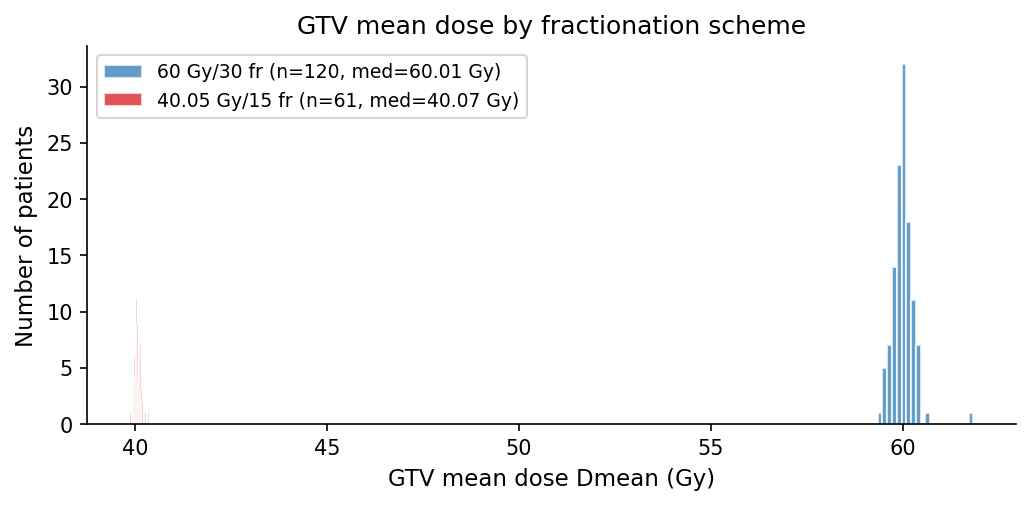

In [4]:
std_dose = modeling.loc[modeling["rt_dose_gy"] == 60.0, "Dmean_gy"]
hypo_dose = modeling.loc[modeling["rt_dose_gy"] == 40.05, "Dmean_gy"]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(std_dose, bins=20, alpha=0.75, color=COLORS[0], edgecolor="white",
        label=f"60 Gy/30 fr (n={len(std_dose)}, med={std_dose.median():.2f} Gy)")
ax.hist(hypo_dose, bins=20, alpha=0.75, color=COLORS[1], edgecolor="white",
        label=f"40.05 Gy/15 fr (n={len(hypo_dose)}, med={hypo_dose.median():.2f} Gy)")
ax.set_xlabel("GTV mean dose Dmean (Gy)")
ax.set_ylabel("Number of patients")
ax.set_title("GTV mean dose by fractionation scheme")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_dmean_by_fractionation.png")
plt.show()

## 3. GTV volume and homogeneity index

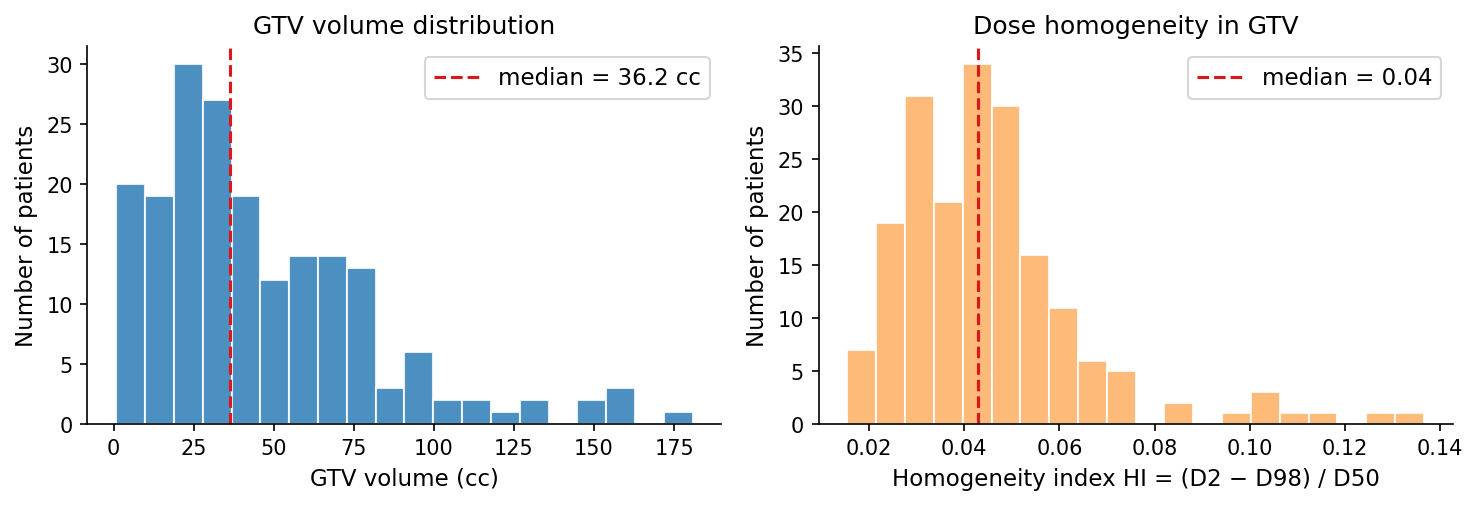

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].hist(modeling["volume_cc"], bins=20, color=COLORS[0], edgecolor="white", alpha=0.85)
axes[0].axvline(modeling["volume_cc"].median(), color=COLORS[1], ls="--",
                label=f"median = {modeling['volume_cc'].median():.1f} cc")
axes[0].set_xlabel("GTV volume (cc)")
axes[0].set_ylabel("Number of patients")
axes[0].set_title("GTV volume distribution")
axes[0].legend()

axes[1].hist(modeling["HI_gy"], bins=20, color=COLORS[2], edgecolor="white", alpha=0.85)
axes[1].axvline(modeling["HI_gy"].median(), color=COLORS[1], ls="--",
                label=f"median = {modeling['HI_gy'].median():.2f}")
axes[1].set_xlabel("Homogeneity index HI = (D2 − D98) / D50")
axes[1].set_ylabel("Number of patients")
axes[1].set_title("Dose homogeneity in GTV")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_volume_hi.png")
plt.show()

## 4. DVH overlay — median-Dmean patient per scheme

60 Gy representative: patient 83, Dmean=60.01 Gy
40.05 Gy representative: patient 100, Dmean=40.07 Gy


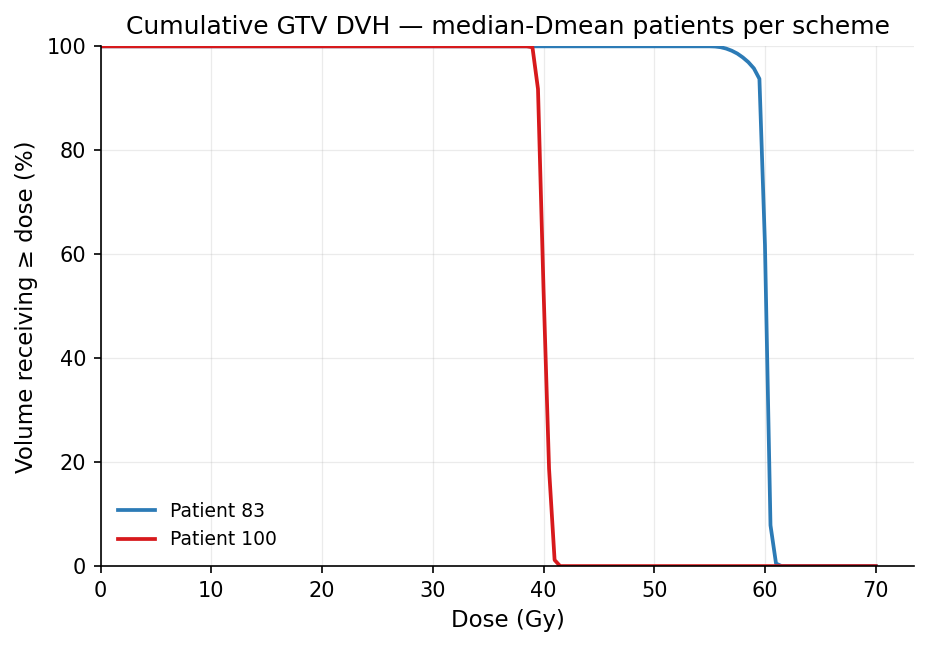

In [6]:
def median_dmean_patient(frame: pd.DataFrame, target_dose: float) -> str:
    sub = frame[frame["rt_dose_gy"] == target_dose].copy()
    median_val = sub["Dmean_gy"].median()
    idx = (sub["Dmean_gy"] - median_val).abs().idxmin()
    return str(int(sub.loc[idx, "patient_id"]))

std_pid = median_dmean_patient(modeling, 60.0)
hypo_pid = median_dmean_patient(modeling, 40.05)

std_dmean = modeling.loc[modeling["patient_id"] == int(std_pid), "Dmean_gy"].iloc[0]
hypo_dmean = modeling.loc[modeling["patient_id"] == int(hypo_pid), "Dmean_gy"].iloc[0]
print(f"60 Gy representative: patient {std_pid}, Dmean={std_dmean:.2f} Gy")
print(f"40.05 Gy representative: patient {hypo_pid}, Dmean={hypo_dmean:.2f} Gy")

plot_dvh_overlay(
    [std_pid, hypo_pid],
    title="Cumulative GTV DVH — median-Dmean patients per scheme",
    save_path=FIGURES_DIR / "02_dvh_overlay_median.png",
)
plt.show()

## 5. Cohort-mean cumulative DVH (60 Gy vs 40.05 Gy groups)

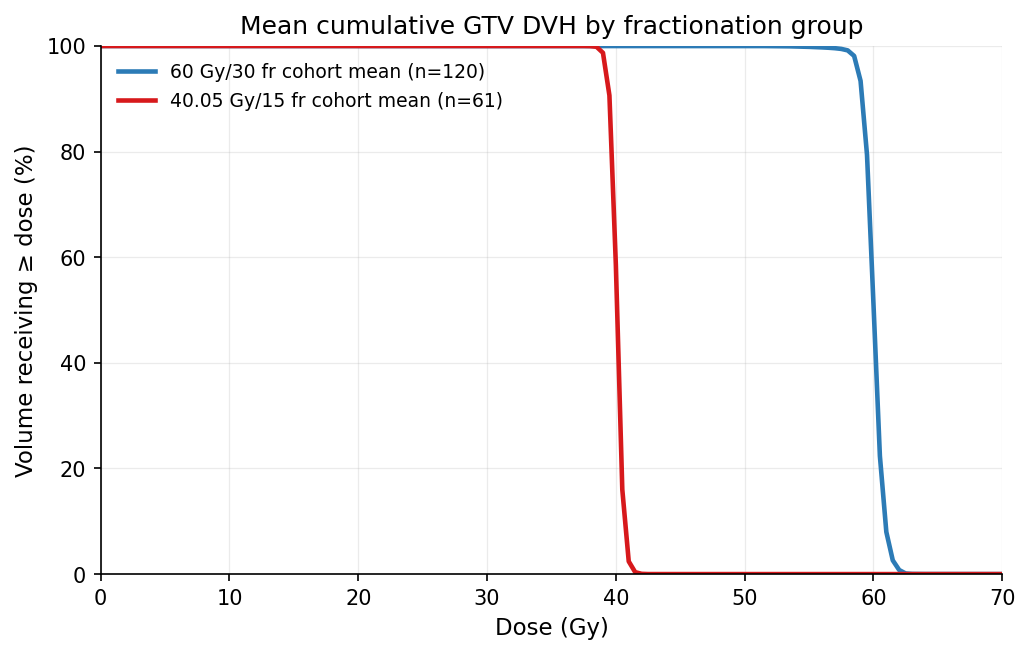

In [7]:
def cohort_mean_dvh(frame: pd.DataFrame, target_dose: float):
    sub = frame[frame["rt_dose_gy"] == target_dose]
    curves = [load_dvh_curve(str(int(pid))) for pid in sub["patient_id"]]
    dose = curves[0][0]
    matrix = np.vstack([c[1] for c in curves])
    return dose, matrix.mean(axis=0), len(sub)

dose_std, mean_std, n_std = cohort_mean_dvh(modeling, 60.0)
dose_hypo, mean_hypo, n_hypo = cohort_mean_dvh(modeling, 40.05)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(dose_std, mean_std, lw=2.2, color=COLORS[0],
        label=f"60 Gy/30 fr cohort mean (n={n_std})")
ax.plot(dose_hypo, mean_hypo, lw=2.2, color=COLORS[1],
        label=f"40.05 Gy/15 fr cohort mean (n={n_hypo})")
ax.set_xlim(0, 70)
ax.set_ylim(0, 100)
ax.set_xlabel("Dose (Gy)")
ax.set_ylabel("Volume receiving ≥ dose (%)")
ax.set_title("Mean cumulative GTV DVH by fractionation group")
ax.legend(fontsize=9, frameon=False)
ax.grid(True, alpha=0.25, lw=0.6)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_dvh_cohort_mean.png")
plt.show()

## 6. Key metric correlations

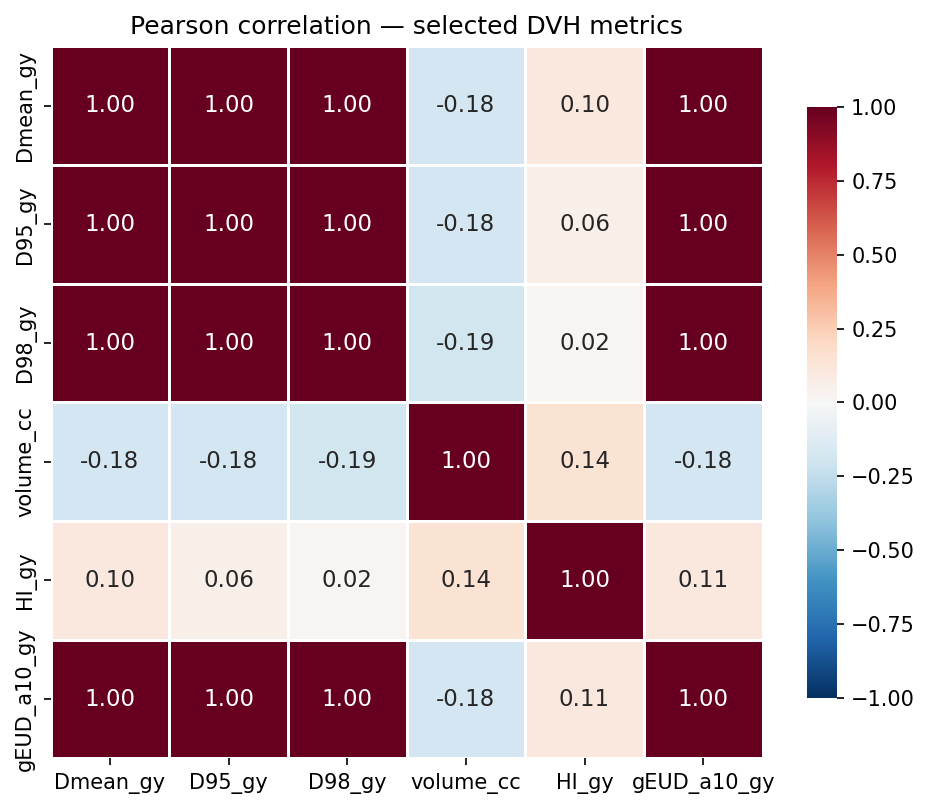

In [8]:
corr_cols = ["Dmean_gy", "D95_gy", "D98_gy", "volume_cc", "HI_gy", "gEUD_a10_gy"]
corr = modeling[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Pearson correlation — selected DVH metrics")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_dvh_correlation.png")
plt.show()